In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error, median_absolute_error, explained_variance_score, max_error

In [63]:
def blackbox(signal):
    signal_train = signal[0:len(signal) // 2]
    signal_test = signal[len(signal) // 2:]
    
    plt.figure()
    plt.plot(signal_train)
    plt.title("Train signal")

    plt.figure()
    plt.plot(signal_test)
    plt.title("Test signal")

    Y_fft = np.fft.fft(signal_train)
    freqs = np.fft.fftfreq(len(signal_train), 1)
    pos_mask = freqs >= 0
    Y_fft_pos = Y_fft[pos_mask]
    freqs_pos = freqs[pos_mask]
    plt.figure()
    plt.plot(freqs, Y_fft)
    plt.title("Frequency vs Strength curve")
    

    mse_scores = []
    min_score = np.inf
    best_threshold = 0
    for i in np.arange(0,1,0.001):
        threshold = i
        lpf_mask = np.abs(freqs) < threshold
        Y_fft_lpf = Y_fft * lpf_mask
        y_time_domain = np.fft.ifft(Y_fft_lpf).real
        mse   = mean_squared_error(signal_test, y_time_domain)
        mse_scores.append(mse)
        if mse < min_score:
            min_score = mse
            best_threshold = i
    print("Best Threshold Frequency: ", best_threshold)
    print("Best MSE value: ", min_score)
    plt.figure()
    plt.plot(np.arange(0,1,0.001), mse_scores)
    plt.title("Threshold vs MSE curve")

    lpf_mask = np.abs(freqs) < best_threshold
    Y_fft_lpf = Y_fft * lpf_mask
    freqs_lpf = freqs * lpf_mask
    plt.figure()
    plt.plot(freqs_lpf, Y_fft_lpf)
    plt.title("Frequency vs Strength (LPF) curve")
    plt.xlim(-1 * best_threshold - 0.1, best_threshold + 0.1)

    y_time_domain = np.fft.ifft(Y_fft_lpf).real
    plt.figure()
    plt.plot(y_time_domain)
    plt.title("Reconstructed prediction curve")

    
    def regression_comparison_table(y_true, y_dnn, y_opt):
    
        def compute_metrics(y_true, y_pred):
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae  = mean_absolute_error(y_true, y_pred)
            r2   = r2_score(y_true, y_pred)
            medae = median_absolute_error(y_true, y_pred)
            evs = explained_variance_score(y_true, y_pred)
            maxe = max_error(y_true, y_pred)
    
            return {
                "RMSE": rmse,
                "MAE": mae,
                "R2": r2,
                "MedAE": medae,
                "ExplainedVariance": evs,
                "MaxError": maxe
            }
    
        dnn_metrics = compute_metrics(y_true, y_dnn)
        opt_metrics = compute_metrics(y_true, y_opt)
    
        print("\nRegression Model Comparison\n")
    
        header = f"{'Metric':<20}{'DNN':>15}{'Optimizer':>15}"
        print(header)
        print("-" * len(header))
    
        for key in dnn_metrics:
            print(f"{key:<20}{dnn_metrics[key]:>15.6f}{opt_metrics[key]:>15.6f}", '             ', np.abs(dnn_metrics[key] - opt_metrics[key]))
    
        return dnn_metrics, opt_metrics

    generate_metrics = regression_comparison_table(signal_test, signal_train, y_time_domain)


In [65]:
#setting up time array and random seed
domain = 8001
step = 0.1
t = np.arange(0, domain, step)


np.random.seed(42)
len(t)

80010

In [67]:
#setting up feature functions and adding random gaussian noise
noise_mf = 10
x1c = 210
x2c = 19
x3c = 100
x4c = 22
x1 = x1c * np.sin(2 * 3.14 * 0.005 * t) + 12 * np.cos(2 * 3.14 * 0.001 * t) + np.random.normal(0,x1c * noise_mf / 100, size=t.shape)

x2 = x2c * np.sign(np.sin(2 * np.pi * 0.001 * t)) + np.random.normal(0, x2c * noise_mf / 100, size=t.shape)

x3 = x3c * (t * 0.0055 - np.floor(0.5 + t * 0.0055)) + np.random.normal(0, x3c * noise_mf / 100, size=t.shape)

x4 = x4c * np.arcsin(np.sin(2 * np.pi * 0.0025 * t)) / np.pi + np.random.normal(0, x4c * noise_mf / 100, size=t.shape)

x5 = np.random.normal(1, 5, size=t.shape) #dc offset

In [69]:
#setting up the label curve
def generate_signal(t, lag):

    # Initialize signal array
    y = np.zeros_like(t)

    # Lag dependency:
    for i in range(10, len(y)):
        y[i] = x1[i-lag] + x2[i-(lag-1)] + x3[i-(lag-2)] + x4[i-(lag-3)] + x5[i]

    # Optional: first valuea can be set to 0 or same as t=0
    y = y[10:]

    return y

80000

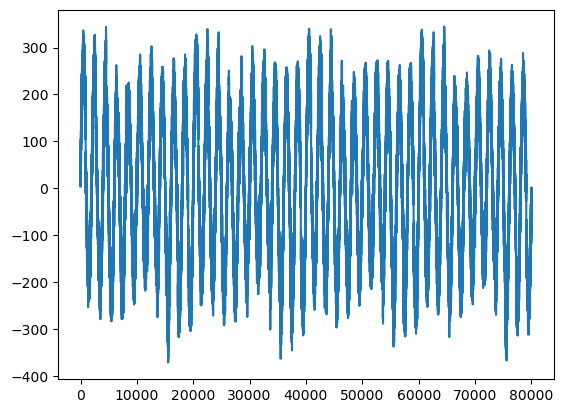

In [71]:
signal = generate_signal(t, 10)
plt.plot(signal)
len(signal)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Best Threshold Frequency:  0.014
Best MSE value:  696.8288906581972

Regression Model Comparison

Metric                          DNN      Optimizer
--------------------------------------------------
RMSE                      35.113068      26.397517               8.71555139604084
MAE                       27.953449      21.078521               6.874927723558365
R2                         0.950720       0.972148               0.021427826542750217
MedAE                     23.471238      17.913880               5.55735816274893
ExplainedVariance          0.950721       0.972149               0.021427826542750217
MaxError                 165.857115     115.133411               50.723704438661045


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


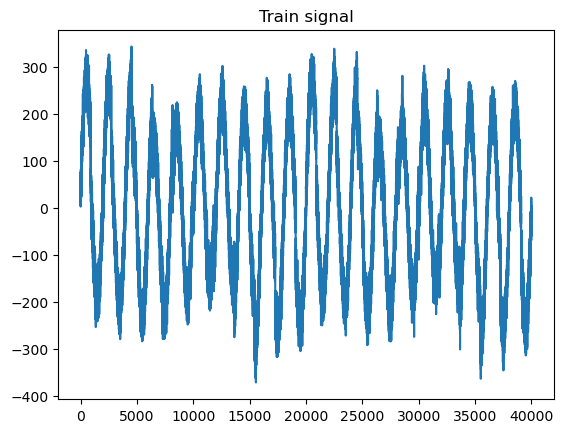

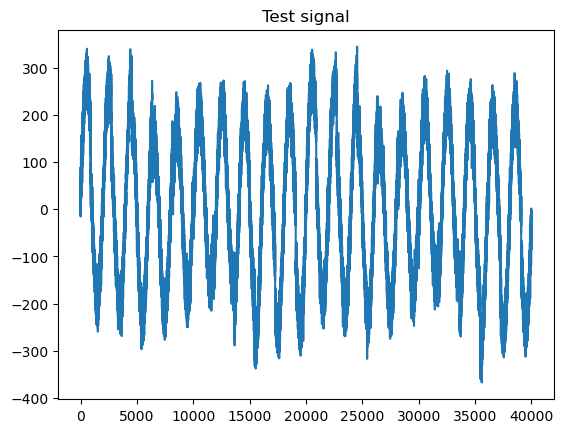

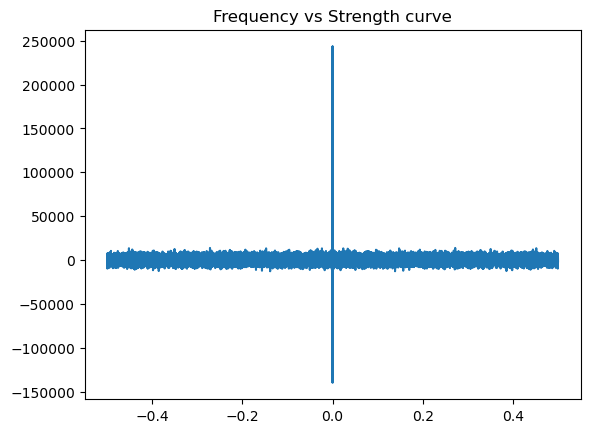

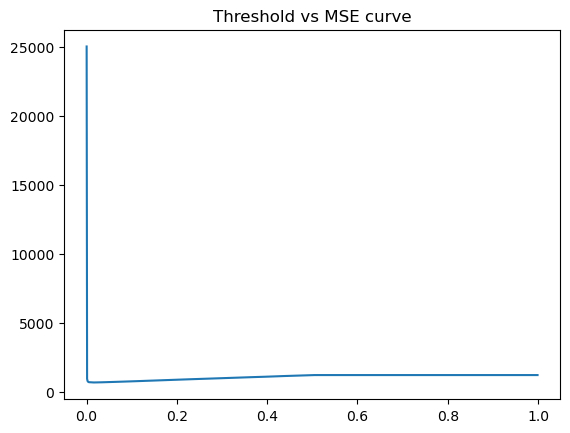

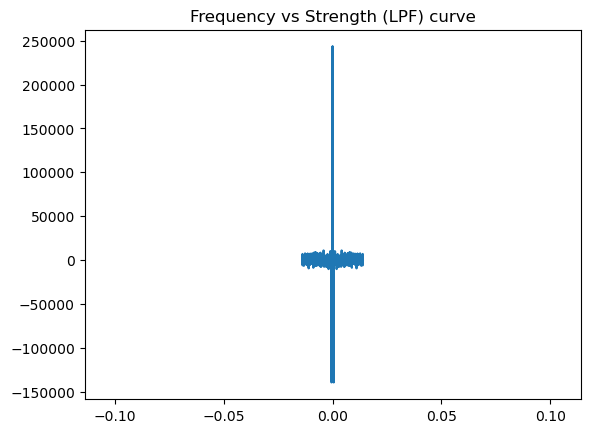

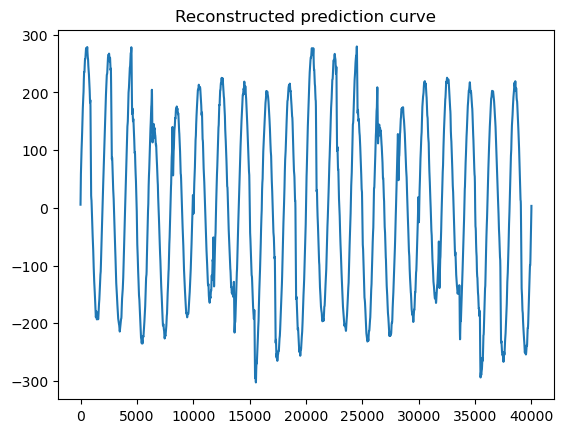

In [73]:
analysis = blackbox(signal)